In [ ]:
from google.colab import drive #import drive module
drive.mount('/content/drive') #folder where drive files appear

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/dataset/animal_dataset.zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000236_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000239_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000240_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000242_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000244_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000245_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000246_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000247_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000248_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000250_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000251_224resized.png  
  i

In [ ]:
!ls /content/dataset

cheetah-resize-224  fox-resize-512    lion-resize-300	wolf-resize-224
cheetah-resize-300  hyena-resize-224  lion-resize-512	wolf-resize-300
cheetah-resize-512  hyena-resize-300  tiger-resize-224	wolf-resize-512
fox-resize-224	    hyena-resize-512  tiger-resize-300
fox-resize-300	    lion-resize-224   tiger-resize-512


In [ ]:
import os #for fle handling and directory handling
import cv2 #for image reding and resizing
import numpy as np # for arrays and numeric operations

from sklearn.model_selection import train_test_split # for training and testing
from sklearn.svm import SVC #import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#for calculating model accuracy

import tensorflow as tf #imports deep learning lib for CNN extraction
from tensorflow.keras.applications import MobileNetV2 #pretrained CNN trained on Imageset
from tensorflow.keras.models import Model #used to create a custom neural network
from tensorflow.keras.layers import GlobalAveragePooling2D #converts CNN feature maps into vectors

import seaborn as sns #data visualization
import matplotlib.pyplot as plt #plotting graphs

In [ ]:
DATASET_PATH = "/content/dataset"

IMG_SIZE = 128 # for fixed image size

images = [] #stores image data
labels = [] #stores class labels

label_map = {} # class to number mapping
current_label = 0

for root, dirs, files in os.walk(DATASET_PATH): #loops through fl=olders and files

    # Skip the top-level directory and intermediate directories that don't contain images directly
    # Images are in directories like /content/dataset/animal-resize-size/resize-size/
    # We want to process only the innermost directories containing images
    if not any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in files):
        continue

    # Extract the animal name for labeling
    # Example root: /content/dataset/hyena-resize-512/resize-512
    # We need 'hyena' from 'hyena-resize-512'
    parent_folder_name = os.path.basename(os.path.dirname(root))
    animal_name = parent_folder_name.split('-')[0]

    if animal_name not in label_map: #Checks if class already exists in dictionary.
        label_map[animal_name] = current_label #Assigns numeric label.
        current_label += 1

    label = label_map[animal_name]

    for file in files:

        if file.lower().endswith(('.png', '.jpg', '.jpeg')):

            img_path = os.path.join(root, file)

            img = cv2.imread(img_path)

            # Check if the image was loaded successfully
            if img is None:
                print(f"Warning: Could not load image {img_path}. Skipping.")
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            images.append(img)
            labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Total Images:", len(X))
print("Classes:", label_map)


Total Images: 5169
Classes: {'hyena': 0, 'fox': 1, 'wolf': 2, 'tiger': 3, 'cheetah': 4, 'lion': 5}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet', #Uses pretrained weights.
    include_top=False, #Removes final classification layer.
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output #Gets CNN output features.
x = GlobalAveragePooling2D()(x) #Converts feature maps into feature vector.

cnn_model = Model(inputs=base_model.input, outputs=x) #Creates new CNN model

In [ ]:
for layer in base_model.layers:
    layer.trainable = False #Prevents CNN weights from changing.

In [ ]:
print("Extracting CNN features...")

train_features = cnn_model.predict(X_train) #Passes images through CNN
test_features = cnn_model.predict(X_test) #Extracts features for testing images.

print("Feature shape:", train_features.shape)

Extracting CNN features...
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 490ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 495ms/step
Feature shape: (4135, 1280)


In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale' #Creates SVM classifier
)

print("Training SVM...")

svm_model.fit(train_features, y_train) #Trains SVM on CNN features.

print("Training Completed")

Training SVM...
Training Completed


In [ ]:
y_pred = svm_model.predict(test_features)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9941972920696325


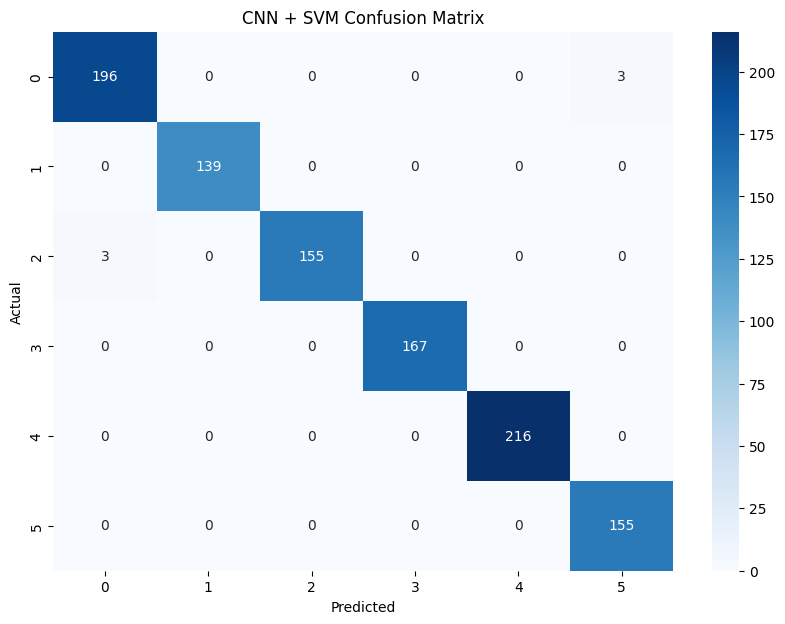

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN + SVM Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       1.00      1.00      1.00       139
           2       1.00      0.98      0.99       158
           3       1.00      1.00      1.00       167
           4       1.00      1.00      1.00       216
           5       0.98      1.00      0.99       155

    accuracy                           0.99      1034
   macro avg       0.99      0.99      0.99      1034
weighted avg       0.99      0.99      0.99      1034

